# Datathon 2026 — DEEP EDA (for Forecast only)

## 15 phân tích sẽ trả lời các câu hỏi quyết định:

| # | Câu hỏi | Quyết định dựa trên |
|---|---|---|
| 1 | Yearly distribution shift thực sự là gì? | Recency weight halflife |
| 2 | Weekly pattern có thay đổi theo năm không? | Profile nên tính từ đâu |
| 3 | J-shape ngày-of-month có giữ trong recent 2020-2022? | EDA features có giá trị không |
| 4 | Sessions/promos tương quan Revenue bao nhiêu? | Cần lag short exogenous không |
| 5 | Promo effect size (days ON vs OFF)? | Feature weight |
| 6 | Tết effect — magnitude thực sự? | Tết features có quan trọng |
| 7 | 11.11/12.12 effect size? | Event features priority |
| 8 | Autocorrelation — dominant lags? | Lag selection |
| 9 | Stationarity test | Có cần differencing? |
| 10 | Outlier days — là noise hay signal? | Clipping vs keeping |
| 11 | Revenue ↔ COGS relationship stability? | Joint vs independent model |
| 12 | Rolling volatility theo thời gian | Heteroscedasticity treatment |
| 13 | Test period characteristics? | Match val với test |
| 14 | Distribution gap train vs test proxy | Calibration necessity |
| 15 | 2022 vs 2023-2024 similarity score | Validation split strategy |

## Setup

In [1]:
!pip install -q lunardate holidays statsmodels

In [2]:
from google.colab import drive
drive.mount('/content/drive')
DATA_DIR = '/content/drive/Shareddrives/Datathon2026/data/'

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from lunardate import LunarDate
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.tsa.seasonal import STL
import holidays

plt.rcParams['figure.figsize'] = (14, 6)
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.0f}'.format)

# Load all
sales       = pd.read_csv(DATA_DIR+'sales.csv',             parse_dates=['Date']).sort_values('Date').reset_index(drop=True)
submission  = pd.read_csv(DATA_DIR+'sample_submission.csv', parse_dates=['Date'])
orders      = pd.read_csv(DATA_DIR+'orders.csv',            parse_dates=['order_date'])
order_items = pd.read_csv(DATA_DIR+'order_items.csv')
promotions  = pd.read_csv(DATA_DIR+'promotions.csv',        parse_dates=['start_date','end_date'])
web_traffic = pd.read_csv(DATA_DIR+'web_traffic.csv',       parse_dates=['date'])
inventory   = pd.read_csv(DATA_DIR+'inventory.csv',         parse_dates=['snapshot_date'])

# Enrich sales
sales['year']  = sales['Date'].dt.year
sales['month'] = sales['Date'].dt.month
sales['day']   = sales['Date'].dt.day
sales['dow']   = sales['Date'].dt.dayofweek
sales['doy']   = sales['Date'].dt.dayofyear
sales['quarter'] = sales['Date'].dt.quarter
sales['week']  = sales['Date'].dt.isocalendar().week.astype(int)
sales['margin']= sales['Revenue'] - sales['COGS']
sales['margin_pct']= sales['margin'] / (sales['Revenue']+1e-8)

print('Sales:', sales.shape, '|', sales['Date'].min().date(), '→', sales['Date'].max().date())
print('Test :', submission.shape, '|', submission['Date'].min().date(), '→', submission['Date'].max().date())

Mounted at /content/drive
Sales: (3833, 12) | 2012-07-04 → 2022-12-31
Test : (548, 3) | 2023-01-01 → 2024-07-01


## Phân tích 1 — **Yearly distribution shift** (boxplot)

Xác định chính xác regime shift xảy ra năm nào.

Yearly statistics:
          mean    median       std       q25       q75        q95       max_
year                                                                        
2012 4,096,673 3,666,205 1,684,324 3,054,029 4,703,189  8,560,209 10,086,534
2013 4,540,190 3,927,167 2,272,147 2,923,604 5,716,766  9,121,695 13,809,349
2014 5,128,345 4,538,183 2,677,531 3,244,854 6,251,989 11,151,484 17,347,427
2015 5,177,901 4,612,174 2,645,186 3,254,430 6,454,103 10,355,572 15,294,818
2016 5,750,384 4,934,152 3,087,505 3,529,964 6,986,702 12,377,179 17,388,183
2017 5,236,067 4,375,381 3,075,067 2,940,959 6,879,971 10,862,333 17,639,271
2018 5,068,829 4,317,415 3,168,626 2,737,800 6,597,217 10,773,938 20,905,271
2019 3,114,524 2,811,324 1,642,734 1,915,593 3,989,319  6,065,294 10,560,541
2020 2,881,181 2,596,347 1,637,312 1,705,357 3,726,860  5,949,971 10,020,939
2021 2,857,643 2,480,974 1,644,091 1,689,418 3,746,326  5,674,060 10,795,905
2022 3,204,791 2,945,502 1,676,108 1,927,819 4,210,213  6

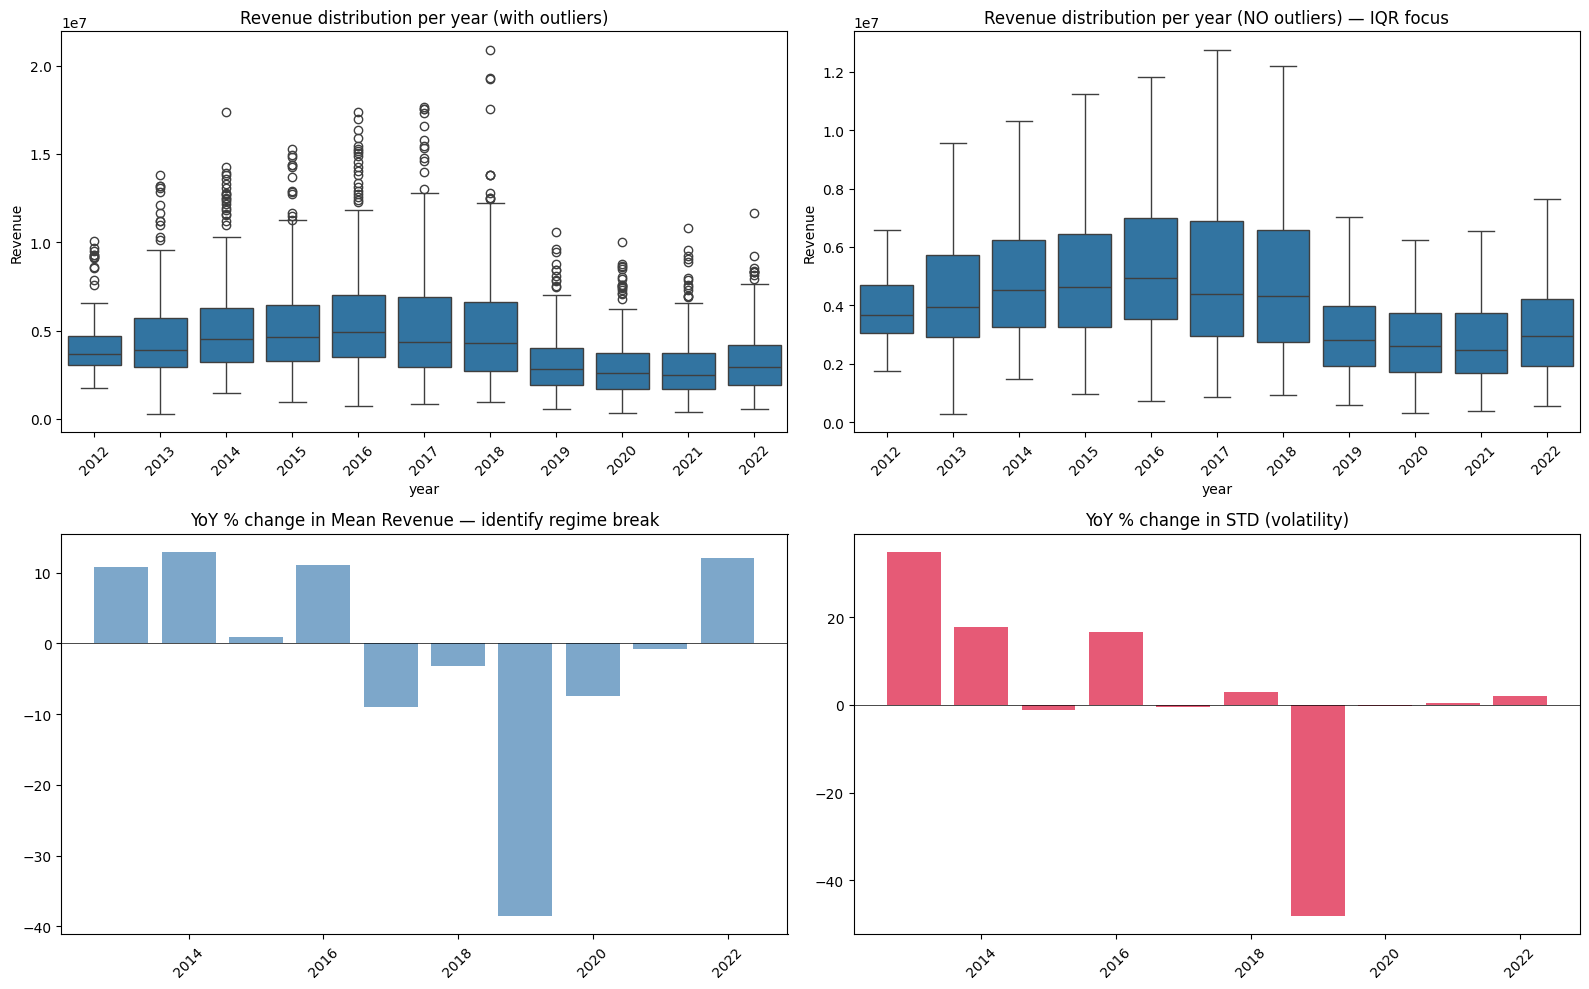


Largest YoY DROPS in mean:
year
2019   -39
2017    -9
2020    -7
Name: yoy_mean_pct, dtype: float64

Regime break identification:
  Year 2019: mean change -38.6%, std change -48.2%


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
sns.boxplot(data=sales, x='year', y='Revenue', ax=axes[0,0], showfliers=True)
axes[0,0].set_title('Revenue distribution per year (with outliers)')
axes[0,0].tick_params(axis='x', rotation=45)

sns.boxplot(data=sales, x='year', y='Revenue', ax=axes[0,1], showfliers=False)
axes[0,1].set_title('Revenue distribution per year (NO outliers) — IQR focus')
axes[0,1].tick_params(axis='x', rotation=45)

# Stats per year
yr_stats = sales.groupby('year').agg(
    mean=('Revenue','mean'), median=('Revenue','median'),
    std=('Revenue','std'), q25=('Revenue', lambda x: x.quantile(0.25)),
    q75=('Revenue', lambda x: x.quantile(0.75)), q95=('Revenue', lambda x: x.quantile(0.95)),
    max_=('Revenue','max')
).round(0)
print('Yearly statistics:')
print(yr_stats)

# Detect regime shift via year-over-year ratio
yr_stats['yoy_mean_pct'] = yr_stats['mean'].pct_change() * 100
yr_stats['yoy_std_pct']  = yr_stats['std'].pct_change() * 100

# Plot shift
axes[1,0].bar(yr_stats.index, yr_stats['yoy_mean_pct'], color='steelblue', alpha=0.7, label='Mean YoY %')
axes[1,0].axhline(0, color='k', lw=0.5)
axes[1,0].set_title('YoY % change in Mean Revenue — identify regime break')
axes[1,0].tick_params(axis='x', rotation=45)

axes[1,1].bar(yr_stats.index, yr_stats['yoy_std_pct'], color='crimson', alpha=0.7, label='Std YoY %')
axes[1,1].axhline(0, color='k', lw=0.5)
axes[1,1].set_title('YoY % change in STD (volatility)')
axes[1,1].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print('\nLargest YoY DROPS in mean:')
print(yr_stats['yoy_mean_pct'].nsmallest(3))
print('\nRegime break identification:')
for y in yr_stats.index[1:]:
    if abs(yr_stats.loc[y, 'yoy_mean_pct']) > 15:
        print(f'  Year {y}: mean change {yr_stats.loc[y,"yoy_mean_pct"]:+.1f}%, std change {yr_stats.loc[y,"yoy_std_pct"]:+.1f}%')

## Phân tích 2 — **Weekly pattern by year** (DOW × Year heatmap)

Check: pattern tuần ổn định qua năm hay thay đổi?

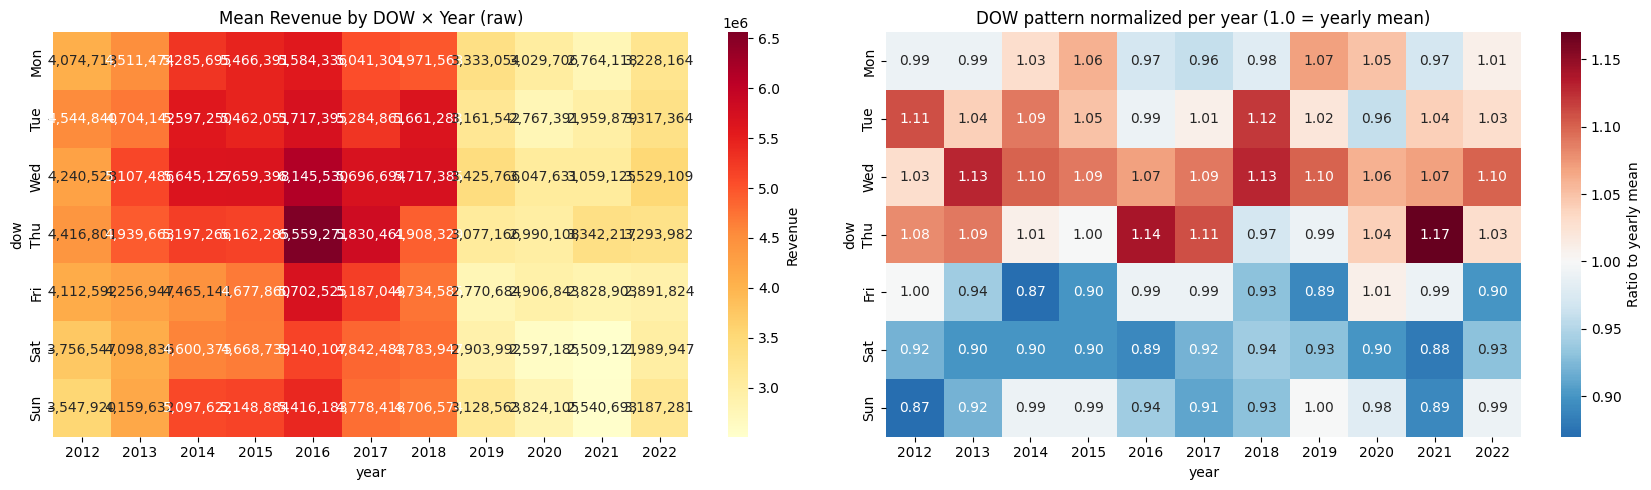

DOW amplitude (max/min) per year:
year
2012   1
2013   1
2014   1
2015   1
2016   1
2017   1
2018   1
2019   1
2020   1
2021   1
2022   1
dtype: float64

Peak DOW per year:
year
2012    Tue
2013    Wed
2014    Wed
2015    Wed
2016    Thu
2017    Thu
2018    Wed
2019    Wed
2020    Wed
2021    Thu
2022    Wed
dtype: object


In [4]:
piv = sales.pivot_table(index='dow', columns='year', values='Revenue', aggfunc='mean')
piv_normalized = piv / piv.mean(axis=0)  # Normalize per year để so sánh shape

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
sns.heatmap(piv.round(0), annot=True, fmt=',.0f', cmap='YlOrRd', ax=axes[0],
            yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], cbar_kws={'label':'Revenue'})
axes[0].set_title('Mean Revenue by DOW × Year (raw)')

sns.heatmap(piv_normalized.round(2), annot=True, fmt='.2f', cmap='RdBu_r', center=1.0, ax=axes[1],
            yticklabels=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'], cbar_kws={'label':'Ratio to yearly mean'})
axes[1].set_title('DOW pattern normalized per year (1.0 = yearly mean)')
plt.tight_layout(); plt.show()

print('DOW amplitude (max/min) per year:')
print((piv.max(axis=0) / piv.min(axis=0)).round(2))
print('\nPeak DOW per year:')
peak_dow = piv.idxmax(axis=0).map({0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'})
print(peak_dow)

## Phân tích 3 — **Day-of-month J-shape**: có giữ trong recent 2020-2022?

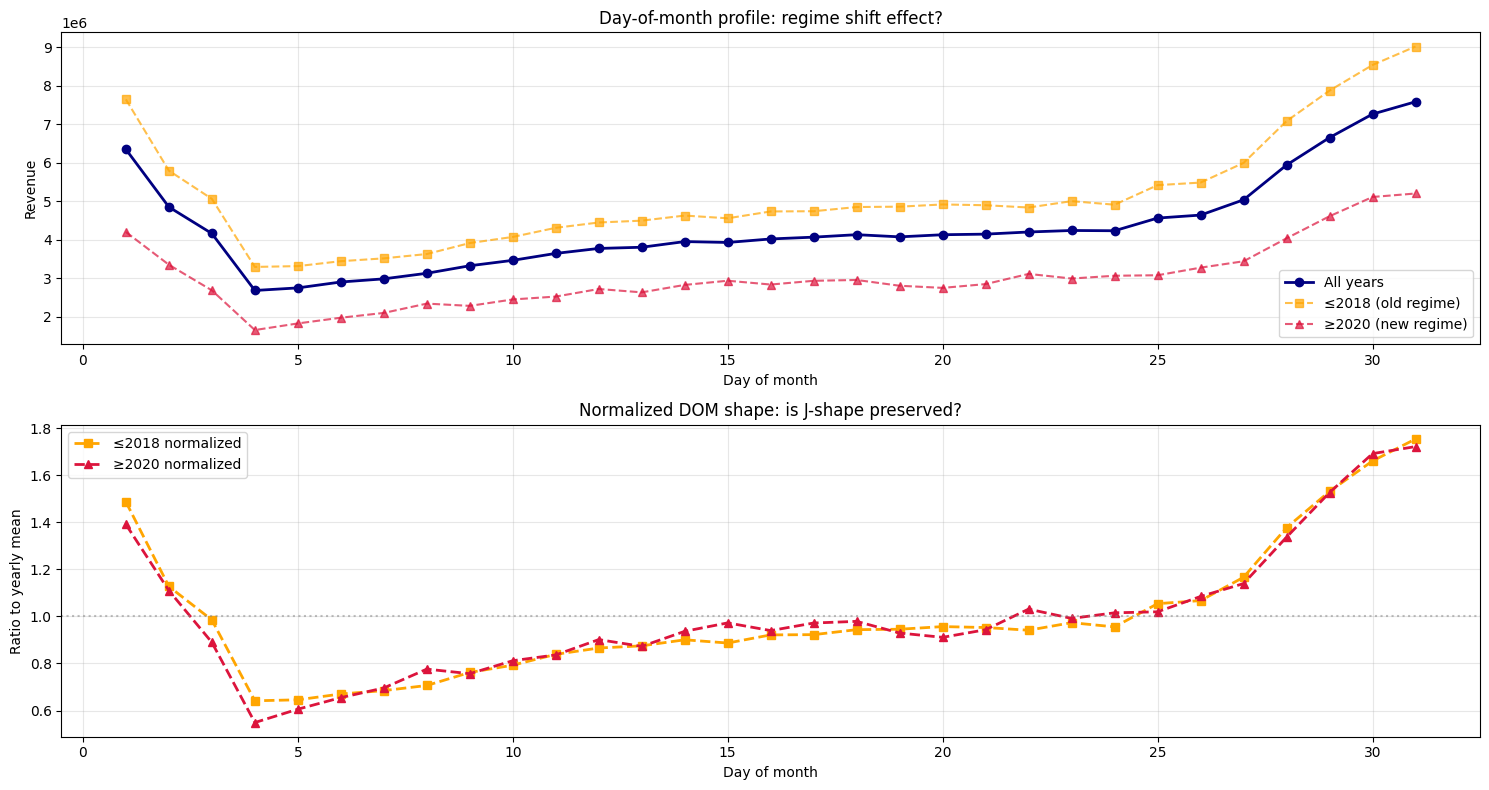

DOM amplitude: old 2.74x | recent 3.14x
Peak DOM old:    31 (9,015,669)
Peak DOM recent: 31 (5,201,019)
Valley DOM recent: 4 (1,657,319)

Correlation old-DOM vs recent-DOM (normalized): 0.9861
  → Shape stable → profile_day useful


In [5]:
dom_all    = sales.groupby('day')['Revenue'].mean()
dom_old    = sales[sales['year']<=2018].groupby('day')['Revenue'].mean()
dom_recent = sales[sales['year']>=2020].groupby('day')['Revenue'].mean()

# Normalize để so sánh shape
dom_old_n    = dom_old / dom_old.mean()
dom_recent_n = dom_recent / dom_recent.mean()
dom_all_n    = dom_all / dom_all.mean()

fig, axes = plt.subplots(2, 1, figsize=(15, 8))
axes[0].plot(dom_all.index, dom_all.values, 'o-', label='All years', color='navy', lw=2)
axes[0].plot(dom_old.index, dom_old.values, 's--', label='≤2018 (old regime)', color='orange', alpha=0.7)
axes[0].plot(dom_recent.index, dom_recent.values, '^--', label='≥2020 (new regime)', color='crimson', alpha=0.7)
axes[0].set_xlabel('Day of month'); axes[0].set_ylabel('Revenue')
axes[0].set_title('Day-of-month profile: regime shift effect?')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(dom_old_n.index, dom_old_n.values, 's--', label='≤2018 normalized', color='orange', lw=2)
axes[1].plot(dom_recent_n.index, dom_recent_n.values, '^--', label='≥2020 normalized', color='crimson', lw=2)
axes[1].axhline(1.0, color='gray', ls=':', alpha=0.5)
axes[1].set_xlabel('Day of month'); axes[1].set_ylabel('Ratio to yearly mean')
axes[1].set_title('Normalized DOM shape: is J-shape preserved?')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'DOM amplitude: old {dom_old.max()/dom_old.min():.2f}x | recent {dom_recent.max()/dom_recent.min():.2f}x')
print(f'Peak DOM old:    {dom_old.idxmax()} ({dom_old.max():,.0f})')
print(f'Peak DOM recent: {dom_recent.idxmax()} ({dom_recent.max():,.0f})')
print(f'Valley DOM recent: {dom_recent.idxmin()} ({dom_recent.min():,.0f})')

# Correlation between old and recent shape
corr = np.corrcoef(dom_old_n.reindex(dom_recent_n.index).fillna(1).values, dom_recent_n.values)[0,1]
print(f'\nCorrelation old-DOM vs recent-DOM (normalized): {corr:.4f}')
if corr > 0.9: print('  → Shape stable → profile_day useful')
elif corr > 0.7: print('  → Shape similar but not identical')
else: print('  → ⚠️ Shape CHANGED → profile_day from old data MISLEADING')

## Phân tích 4 — **Exogenous correlations** (Pearson + Spearman)

Pearson correlation với Revenue/COGS:
                 Revenue  COGS
n_orders               1     1
n_items                1     1
sessions               0     0
unique_visitors        0     0
page_views             0     0
bounce_rate            0     0
n_active_promos       -0     0
avg_discount          -0     0

Spearman correlation (rank-based, robust):
                 Revenue  COGS
n_orders               1     1
n_items                1     1
unique_visitors        0     0
sessions               0     0
page_views             0     0
bounce_rate           -0    -0
n_active_promos       -0     0
avg_discount          -0     0


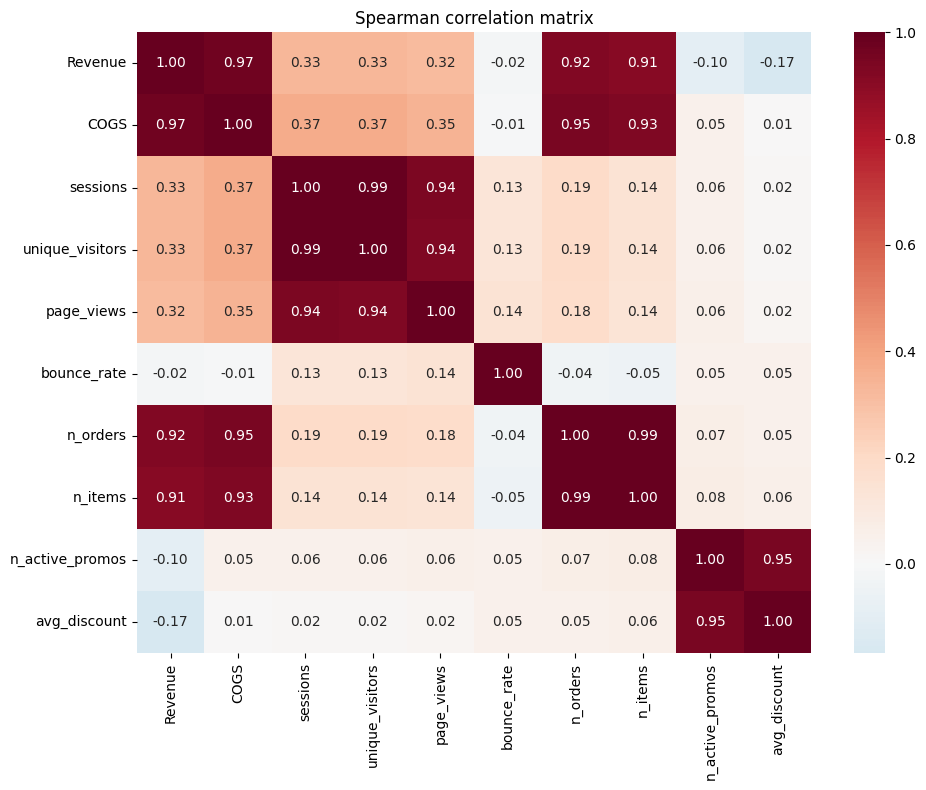


KEY INSIGHT:
  Top 3 Revenue correlations: {'n_orders': 0.923, 'n_items': 0.908, 'unique_visitors': 0.333}


In [6]:
# Daily merge all exogenous
wt_d = web_traffic.groupby('date').agg(sessions=('sessions','sum'), unique_visitors=('unique_visitors','sum'),
                                        page_views=('page_views','sum'), bounce_rate=('bounce_rate','mean')
                                       ).reset_index().rename(columns={'date':'Date'})
od_d = orders.groupby('order_date').size().reset_index(name='n_orders').rename(columns={'order_date':'Date'})
oi_m = order_items.merge(orders[['order_id','order_date']], on='order_id')
it_d = oi_m.groupby('order_date').agg(n_items=('quantity','sum')).reset_index().rename(columns={'order_date':'Date'})

# Promotions daily
all_d = pd.DataFrame({'Date':sales['Date'].unique()}).sort_values('Date')
all_d['n_active_promos'] = all_d['Date'].apply(
    lambda d: int(((promotions['start_date']<=d)&(promotions['end_date']>=d)).sum()))
all_d['avg_discount'] = all_d['Date'].apply(
    lambda d: promotions.loc[(promotions['start_date']<=d)&(promotions['end_date']>=d),'discount_value'].mean())
all_d['avg_discount'] = all_d['avg_discount'].fillna(0)

# Merge
m = sales[['Date','Revenue','COGS']].merge(wt_d, on='Date', how='left').merge(od_d, on='Date', how='left')\
    .merge(it_d, on='Date', how='left').merge(all_d, on='Date', how='left').fillna(0)

# Correlations
exo_cols = ['sessions','unique_visitors','page_views','bounce_rate','n_orders','n_items','n_active_promos','avg_discount']
pearson = m[['Revenue','COGS'] + exo_cols].corr(method='pearson')[['Revenue','COGS']].round(3)
spearman= m[['Revenue','COGS'] + exo_cols].corr(method='spearman')[['Revenue','COGS']].round(3)

print('Pearson correlation với Revenue/COGS:')
print(pearson.drop(['Revenue','COGS']).sort_values('Revenue', ascending=False))
print('\nSpearman correlation (rank-based, robust):')
print(spearman.drop(['Revenue','COGS']).sort_values('Revenue', ascending=False))

# Heatmap full correlation
fig, ax = plt.subplots(figsize=(10, 8))
full_corr = m[['Revenue','COGS']+exo_cols].corr(method='spearman')
sns.heatmap(full_corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Spearman correlation matrix'); plt.tight_layout(); plt.show()

print('\nKEY INSIGHT:')
print(f'  Top 3 Revenue correlations: {spearman["Revenue"].drop(["Revenue","COGS"]).nlargest(3).to_dict()}')

## Phân tích 5 — **Promotion effect size**

Promo ON vs OFF:
           rev_mean  rev_median     n
has_promo                            
0         4,524,083   3,819,856  2126
1         3,990,789   3,428,607  1707

  Promo uplift: -11.8% (if >10%: important feature)

By promo level:
             rev_mean     n
promo_level                
None        4,524,083  2126
1           3,974,903  1687
2           5,330,783    20
3                 NaN     0
4+                NaN     0

Welch t-test: t=-6.38, p=1.928e-10 (Significant)


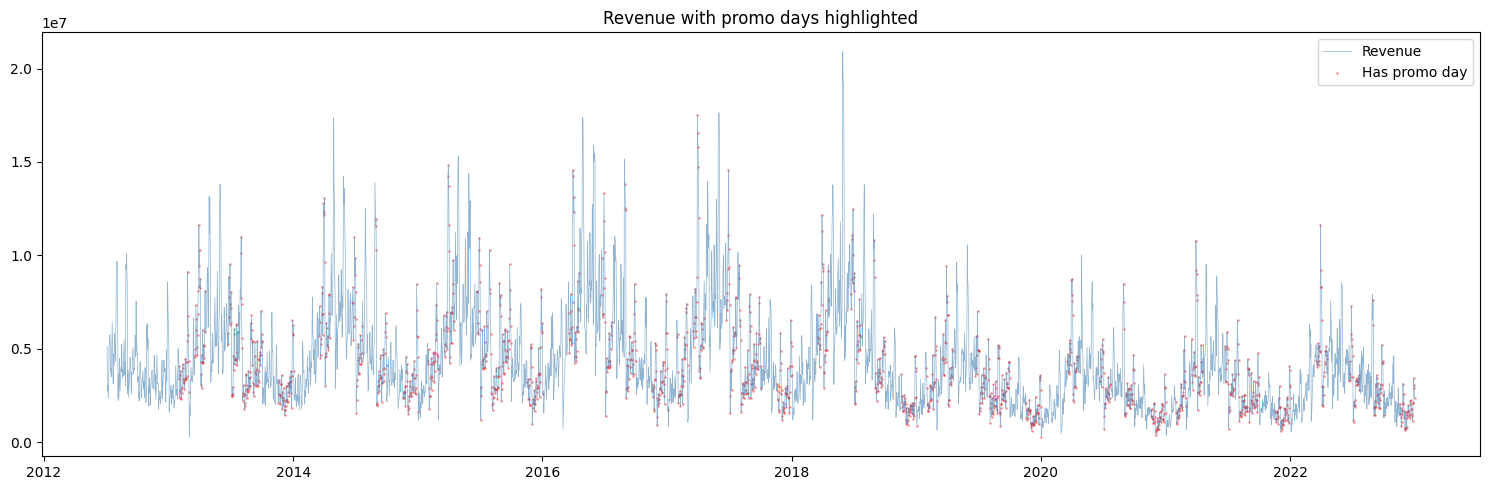

In [7]:
m['has_promo'] = (m['n_active_promos']>0).astype(int)
m['promo_level'] = pd.cut(m['n_active_promos'], bins=[-1,0,1,2,3,100], labels=['None','1','2','3','4+'])

promo_effect = m.groupby('has_promo').agg(rev_mean=('Revenue','mean'), rev_median=('Revenue','median'),
                                            n=('Revenue','size')).round(0)
print('Promo ON vs OFF:')
print(promo_effect)
if len(promo_effect)>=2:
    ratio = promo_effect.loc[1,'rev_mean'] / promo_effect.loc[0,'rev_mean']
    print(f'\n  Promo uplift: {(ratio-1)*100:+.1f}% (if >10%: important feature)')

# By promo level
print('\nBy promo level:')
print(m.groupby('promo_level').agg(rev_mean=('Revenue','mean'), n=('Revenue','size')).round(0))

# T-test
if len(promo_effect)>=2:
    t, p = stats.ttest_ind(m.loc[m['has_promo']==1,'Revenue'], m.loc[m['has_promo']==0,'Revenue'], equal_var=False)
    print(f'\nWelch t-test: t={t:.2f}, p={p:.4g} ({"Significant" if p<0.05 else "Not significant"})')

# Plot over time
fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(m['Date'], m['Revenue'], lw=0.5, color='steelblue', alpha=0.6, label='Revenue')
promo_dates = m[m['has_promo']==1]
ax.scatter(promo_dates['Date'], promo_dates['Revenue'], s=1, color='red', alpha=0.3, label='Has promo day')
ax.set_title('Revenue with promo days highlighted'); ax.legend(); plt.tight_layout(); plt.show()

## Phân tích 6 — **Tết (Lunar New Year) effect magnitude**

Tết effect by phase (baseline = Far_before):
            rev_mean   rev_med    rev_max     n  uplift_%
tet_phase                                                
Far_before 3,183,102 2,854,019 15,158,669  1778         0
Pre21      2,822,396 2,537,166  6,920,880   140       -11
Pre7       2,949,855 2,940,236  5,411,097    60        -7
Tet_week   3,335,638 3,107,259  8,502,203    80         5
Post7      3,506,898 3,247,281  9,128,225   140        10
Far_after  5,774,298 5,148,543 20,905,271  1635        81


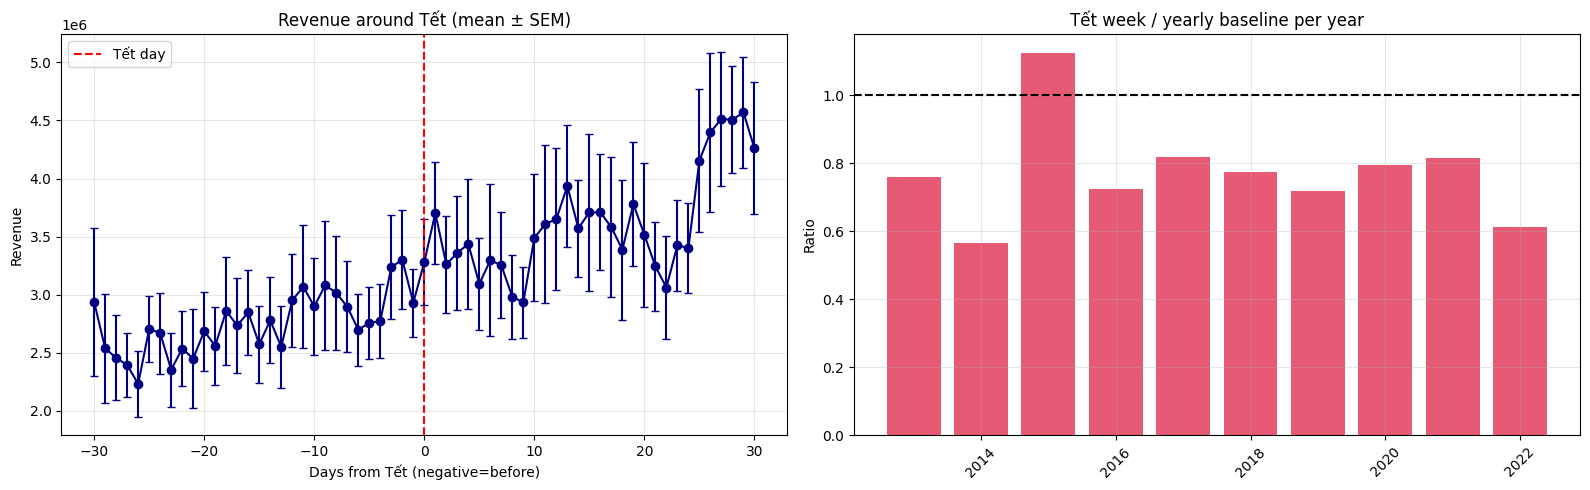


Tết week / baseline mean: 0.77x ± 0.15
  ⚠️ Tết effect SMALL or NEGATIVE — fashion e-commerce dips during Tết!


In [9]:
tet_dates = {}
for y in range(2011, 2026):
    try: tet_dates[y] = pd.Timestamp(LunarDate(y,1,1).toSolarDate())
    except: pass

def days_to_tet(d):
    cand = [tet_dates.get(y) for y in [d.year-1, d.year, d.year+1] if y in tet_dates]
    diffs = [(d - tc).days for tc in cand]
    return min(diffs, key=abs) if diffs else 999

m['days_to_tet'] = m['Date'].apply(days_to_tet)
m['tet_phase'] = pd.cut(m['days_to_tet'], bins=[-366,-21,-7,-1,7,21,366],
                         labels=['Far_before','Pre21','Pre7','Tet_week','Post7','Far_after'])

tet_eff = m.groupby('tet_phase', observed=True).agg(
    rev_mean=('Revenue','mean'), rev_med=('Revenue','median'),
    rev_max=('Revenue','max'), n=('Revenue','size')).round(0)

baseline = tet_eff.loc['Far_before','rev_mean']
tet_eff['uplift_%'] = ((tet_eff['rev_mean'] - baseline) / baseline * 100).round(1)
print('Tết effect by phase (baseline = Far_before):')
print(tet_eff)

# Plot — Revenue vs days_to_tet
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
daily = m[(m['days_to_tet']>=-30) & (m['days_to_tet']<=30)].groupby('days_to_tet')['Revenue'].agg(['mean','std','count'])
axes[0].errorbar(daily.index, daily['mean'], yerr=daily['std']/np.sqrt(daily['count']),
                 marker='o', capsize=3, color='navy')
axes[0].axvline(0, color='red', ls='--', label='Tết day')
axes[0].set_xlabel('Days from Tết (negative=before)'); axes[0].set_ylabel('Revenue')
axes[0].set_title('Revenue around Tết (mean ± SEM)'); axes[0].grid(alpha=0.3); axes[0].legend()

# Tết effect per year (is it same every year?)
m['year'] = m['Date'].dt.year # Add 'year' column to m DataFrame
tet_week = m[m['days_to_tet'].between(0, 7)].groupby(m['Date'].dt.year)['Revenue'].mean()
baseline_year = m.groupby('year')['Revenue'].mean()
tet_ratio = (tet_week / baseline_year).dropna()
axes[1].bar(tet_ratio.index, tet_ratio.values, color='crimson', alpha=0.7)
axes[1].axhline(1.0, color='k', ls='--')
axes[1].set_title('Tết week / yearly baseline per year'); axes[1].set_ylabel('Ratio')
axes[1].tick_params(axis='x', rotation=45); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f'\nTết week / baseline mean: {tet_ratio.mean():.2f}x \u00b1 {tet_ratio.std():.2f}')
if tet_ratio.mean() < 1.1: print('  ⚠️ Tết effect SMALL or NEGATIVE — fashion e-commerce dips during Tết!')

## Phân tích 7 — **11.11 / 12.12 / Black Friday effect size**

In [10]:
m['is_1111'] = ((m['Date'].dt.month==11)&(m['Date'].dt.day==11)).astype(int)
m['is_1212'] = ((m['Date'].dt.month==12)&(m['Date'].dt.day==12)).astype(int)
m['is_99']   = ((m['Date'].dt.month==9)&(m['Date'].dt.day==9)).astype(int)
m['is_1010'] = ((m['Date'].dt.month==10)&(m['Date'].dt.day==10)).astype(int)
m['is_bf']   = ((m['Date'].dt.month==11)&(m['Date'].dt.dayofweek==4)&(m['Date'].dt.day.between(23,29))).astype(int)

year_mean = m.groupby(m['Date'].dt.year)['Revenue'].transform('mean')
m['rev_vs_year'] = m['Revenue'] / year_mean

events = {'11.11': 'is_1111','12.12':'is_1212','9.9':'is_99','10.10':'is_1010','BlackFri':'is_bf'}
print('Event uplift vs yearly mean:')
res = {}
for name, col in events.items():
    on  = m.loc[m[col]==1, 'rev_vs_year']
    off = m.loc[m[col]==0, 'rev_vs_year']
    if len(on) > 0:
        uplift = (on.mean() - 1) * 100
        t, p = stats.ttest_ind(on, off, equal_var=False) if len(on) > 1 else (0, 1)
        print(f'  {name:10s}: n={len(on):>3} days | uplift={uplift:+6.1f}% | p={p:.4g}')
        res[name] = uplift

Event uplift vs yearly mean:
  11.11     : n= 11 days | uplift= -36.8% | p=3.214e-07
  12.12     : n= 11 days | uplift= -46.6% | p=2.62e-05
  9.9       : n= 11 days | uplift= -21.4% | p=0.003436
  10.10     : n= 11 days | uplift= -32.3% | p=3.612e-05
  BlackFri  : n= 11 days | uplift= -42.5% | p=0.0001372


## Phân tích 8 — **Autocorrelation structure** (ACF / PACF đến lag 1100)

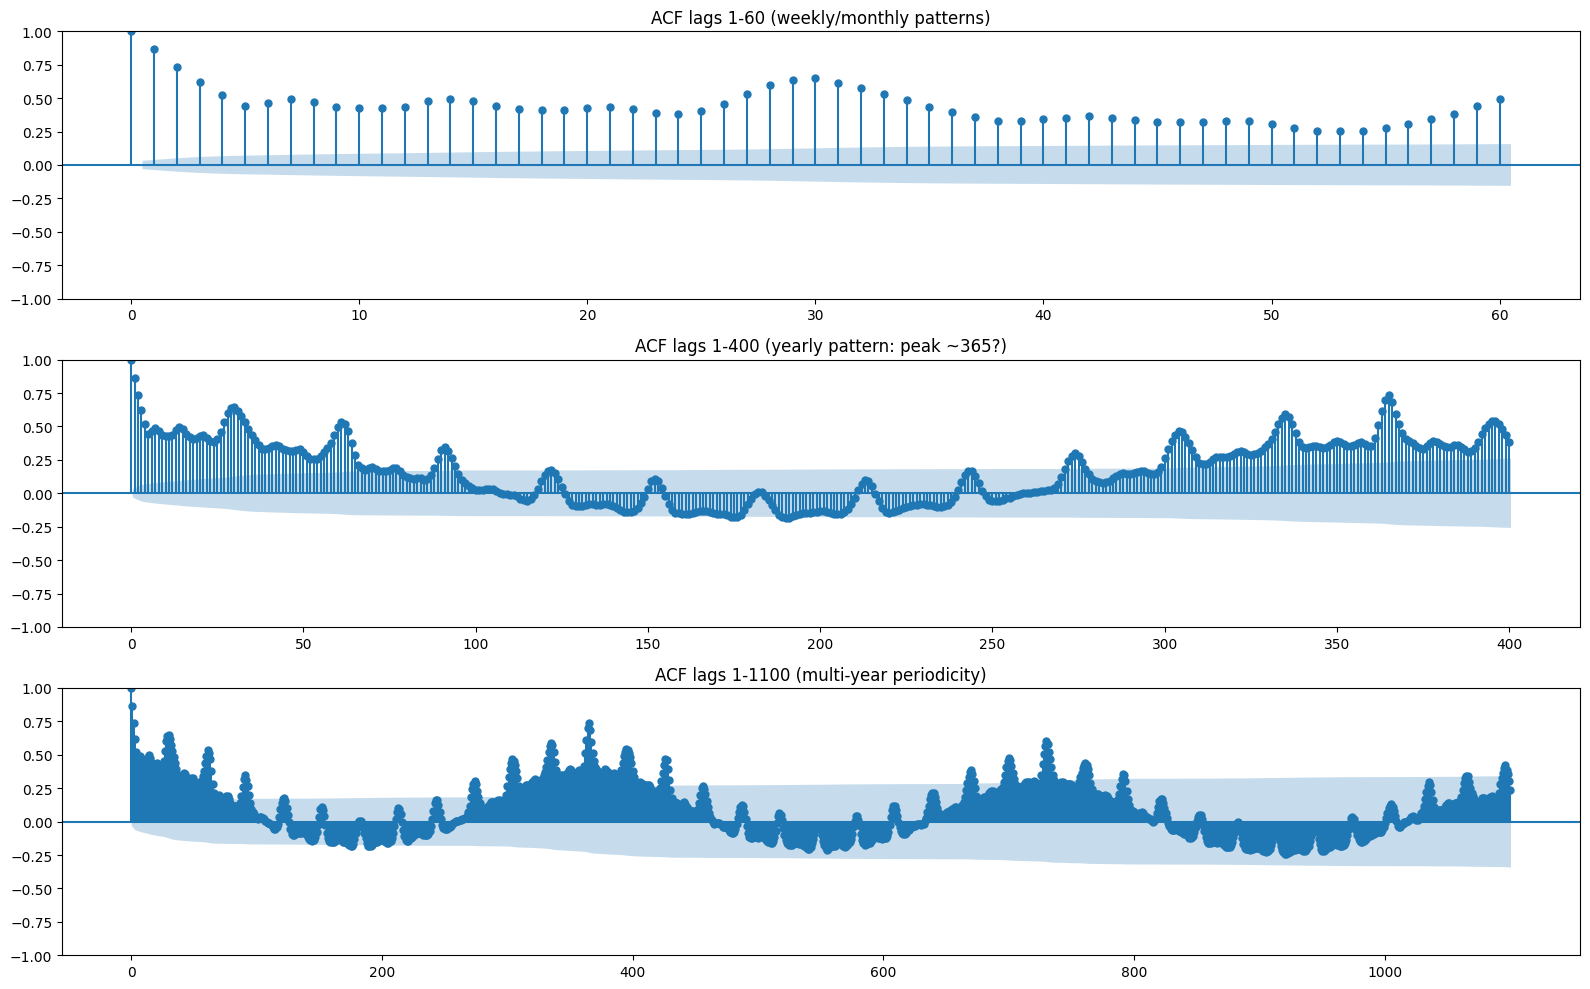

Top 15 ACF peaks (dominant lags):
  Lag  365: ACF = 0.7380
  Lag   30: ACF = 0.6482
  Lag  730: ACF = 0.6057
  Lag  335: ACF = 0.5906
  Lag  395: ACF = 0.5413
  Lag   61: ACF = 0.5353
  Lag   14: ACF = 0.4956
  Lag    7: ACF = 0.4917
  Lag  700: ACF = 0.4729
  Lag  426: ACF = 0.4705
  Lag  304: ACF = 0.4667
  Lag  761: ACF = 0.4364
  Lag   21: ACF = 0.4356
  Lag 1096: ACF = 0.4201
  Lag  350: ACF = 0.3949


In [11]:
# ACF for multiple windows
rev_ts = sales.set_index('Date')['Revenue'].asfreq('D')
fig, axes = plt.subplots(3, 1, figsize=(16, 10))
plot_acf(rev_ts.dropna(), lags=60, ax=axes[0])
axes[0].set_title('ACF lags 1-60 (weekly/monthly patterns)')
plot_acf(rev_ts.dropna(), lags=400, ax=axes[1])
axes[1].set_title('ACF lags 1-400 (yearly pattern: peak ~365?)')
plot_acf(rev_ts.dropna(), lags=1100, ax=axes[2])
axes[2].set_title('ACF lags 1-1100 (multi-year periodicity)')
plt.tight_layout(); plt.show()

# Extract dominant lags
acf_vals = acf(rev_ts.dropna(), nlags=1100)
# Local maxima
from scipy.signal import find_peaks
peaks, _ = find_peaks(acf_vals, height=0.1, distance=5)
print('Top 15 ACF peaks (dominant lags):')
top_peaks = sorted(peaks, key=lambda l: -acf_vals[l])[:15]
for p in top_peaks:
    print(f'  Lag {p:>4}: ACF = {acf_vals[p]:.4f}')

## Phân tích 9 — **Stationarity test** (ADF)

In [12]:
for name, s in [('Revenue raw', sales['Revenue']),
                ('Revenue log', np.log1p(sales['Revenue'])),
                ('Revenue diff(1)', sales['Revenue'].diff().dropna()),
                ('Revenue diff(7)', sales['Revenue'].diff(7).dropna()),
                ('Revenue diff(365)', sales['Revenue'].diff(365).dropna())]:
    adf = adfuller(s.dropna())
    verdict = 'stationary' if adf[1] < 0.05 else 'non-stationary'
    print(f'{name:22s}: ADF={adf[0]:>8.3f}, p={adf[1]:.4g} — {verdict}')

Revenue raw           : ADF=  -2.525, p=0.1095 — non-stationary
Revenue log           : ADF=  -2.314, p=0.1674 — non-stationary
Revenue diff(1)       : ADF= -23.532, p=0 — stationary
Revenue diff(7)       : ADF= -13.668, p=1.478e-25 — stationary
Revenue diff(365)     : ADF=  -5.579, p=1.414e-06 — stationary


## Phân tích 10 — **Outlier detection**: ngày nào cực đoan?

Top 30 POSITIVE outliers (z > ...):
      Date    Revenue  z_rev  month  day  dow
2020-04-29 10,020,939      3      4   29    2
2013-02-25  9,128,225      3      2   25    0
2021-04-29  9,535,515      3      4   29    3
2022-03-30 11,643,209      3      3   30    2
2014-04-29 17,347,427      3      4   29    1
2014-12-28  8,484,445      3     12   28    6
2021-09-28  4,749,133      3      9   28    1
2012-09-27  7,556,893      3      9   27    3
2018-08-01 13,786,352      3      8    1    2
2021-11-30  2,987,950      3     11   30    1
2019-05-30 10,560,541      3      5   30    3
2020-12-28  3,627,798      3     12   28    0
2019-02-25  6,710,330      3      2   25    0
2017-12-29  6,520,227      3     12   29    4
2015-09-27  9,527,330      3      9   27    6
2021-02-25  5,675,844      3      2   25    3
2021-03-30 10,795,905      3      3   30    1
2020-09-28  4,681,424      3      9   28    0
2012-12-28  8,573,663      3     12   28    4
2015-02-25  8,502,203      3      2   25    

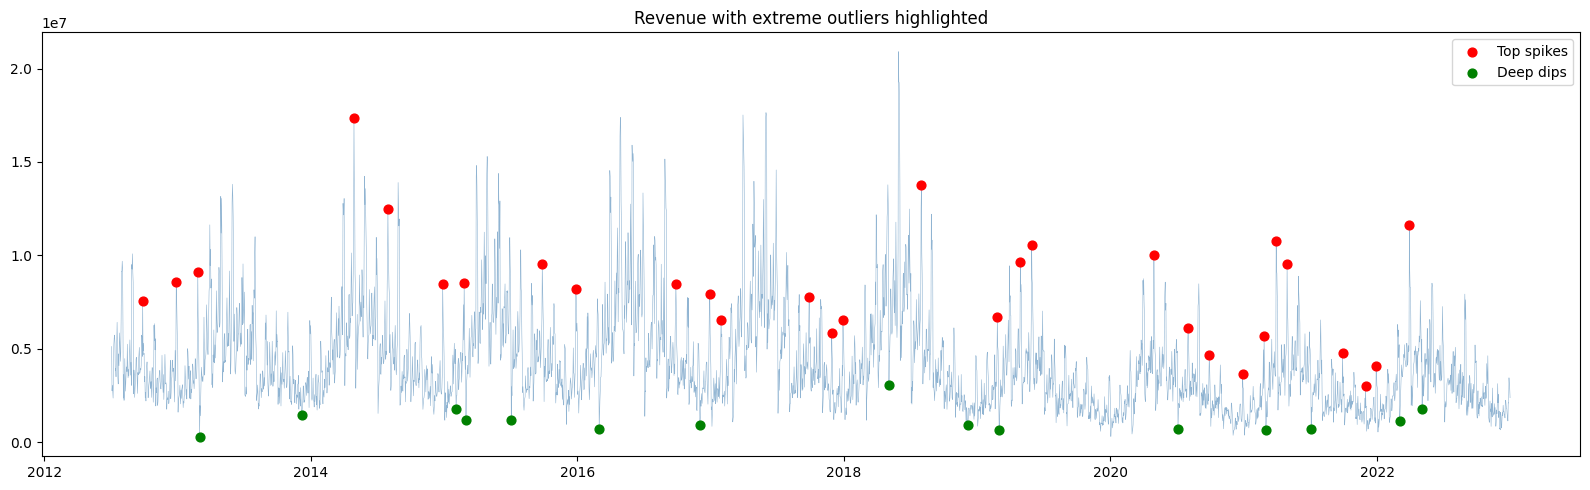


Month distribution of top-30 positive spikes:
month
1     1
2     4
3     2
4     4
5     1
7     1
8     2
9     6
11    2
12    7
Name: count, dtype: int64

DOW distribution of top-30 positive spikes:
dow
0    6
1    6
2    5
3    7
4    2
5    1
6    3
Name: count, dtype: int64


In [13]:
# Z-score by rolling window
sales['rev_roll_mean'] = sales['Revenue'].rolling(30, min_periods=1, center=True).mean()
sales['rev_roll_std']  = sales['Revenue'].rolling(30, min_periods=1, center=True).std()
sales['z_rev'] = (sales['Revenue'] - sales['rev_roll_mean']) / (sales['rev_roll_std']+1e-8)

top_outliers = sales.nlargest(30, 'z_rev')[['Date','Revenue','z_rev','month','day','dow']]
bot_outliers = sales.nsmallest(15, 'z_rev')[['Date','Revenue','z_rev','month','day','dow']]

print('Top 30 POSITIVE outliers (z > ...):')
print(top_outliers.to_string(index=False))
print('\nTop 15 NEGATIVE outliers (deep dips):')
print(bot_outliers.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(sales['Date'], sales['Revenue'], lw=0.4, color='steelblue', alpha=0.6)
ax.scatter(top_outliers['Date'], top_outliers['Revenue'], s=40, color='red', label='Top spikes', zorder=5)
ax.scatter(bot_outliers['Date'], bot_outliers['Revenue'], s=40, color='green', label='Deep dips', zorder=5)
ax.set_title('Revenue with extreme outliers highlighted'); ax.legend()
plt.tight_layout(); plt.show()

# Tell me which months dominate outliers
print('\nMonth distribution of top-30 positive spikes:')
print(top_outliers['month'].value_counts().sort_index())
print('\nDOW distribution of top-30 positive spikes:')
print(top_outliers['dow'].value_counts().sort_index())

## Phân tích 11 — **Revenue ↔ COGS relationship**

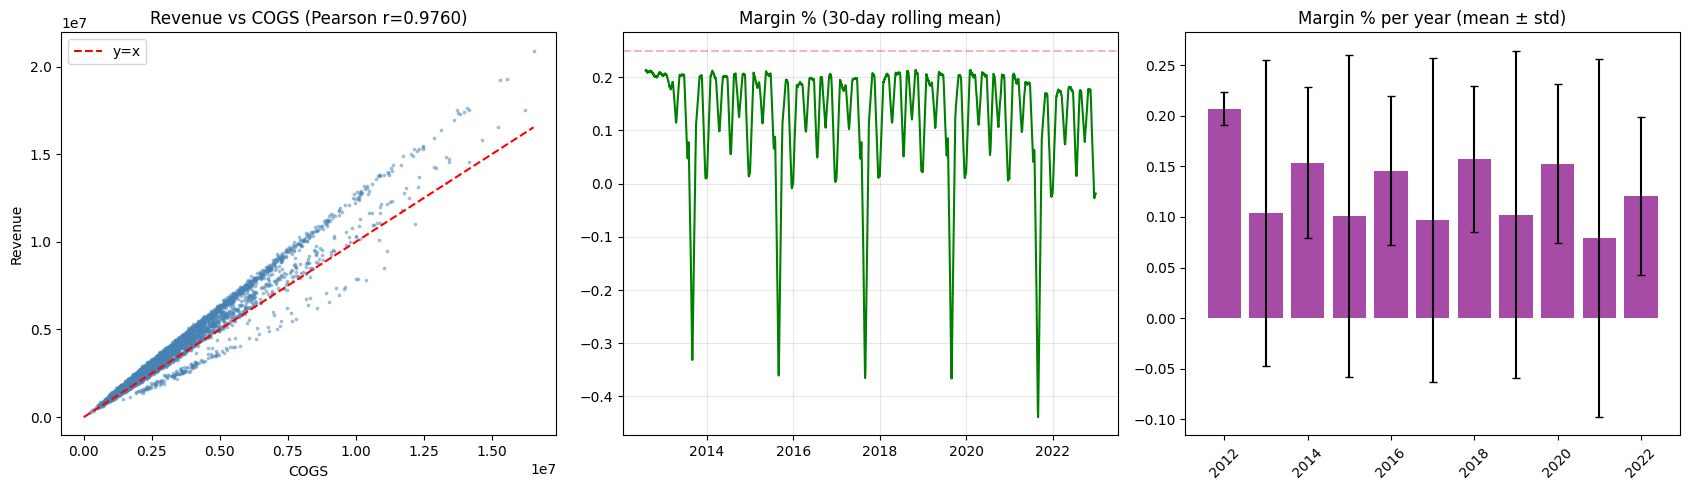

Overall Pearson Revenue-COGS: 0.9760
Margin % stats: mean=0.125, std=0.127
Margin % per year:
      mean  std
year           
2012     0    0
2013     0    0
2014     0    0
2015     0    0
2016     0    0
2017     0    0
2018     0    0
2019     0    0
2020     0    0
2021     0    0
2022     0    0


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Scatter
axes[0].scatter(sales['COGS'], sales['Revenue'], s=3, alpha=0.4, color='steelblue')
axes[0].plot([0, sales['COGS'].max()], [0, sales['COGS'].max()], 'r--', label='y=x')
corr = sales[['Revenue','COGS']].corr().iloc[0,1]
axes[0].set_title(f'Revenue vs COGS (Pearson r={corr:.4f})')
axes[0].set_xlabel('COGS'); axes[0].set_ylabel('Revenue'); axes[0].legend()

# Margin % over time
axes[1].plot(sales['Date'], sales['margin_pct'].rolling(30).mean(), color='green')
axes[1].set_title('Margin % (30-day rolling mean)'); axes[1].axhline(0.25, color='r', ls='--', alpha=0.3)
axes[1].grid(alpha=0.3)

# Margin % per year — stable?
mp = sales.groupby('year')['margin_pct'].agg(['mean','std'])
axes[2].bar(mp.index, mp['mean'], yerr=mp['std'], color='purple', alpha=0.7, capsize=3)
axes[2].set_title('Margin % per year (mean ± std)')
axes[2].tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()

print(f'Overall Pearson Revenue-COGS: {corr:.4f}')
print(f'Margin % stats: mean={sales["margin_pct"].mean():.3f}, std={sales["margin_pct"].std():.3f}')
print(f'Margin % per year:')
print(mp.round(3))

## Phân tích 12 — **Rolling volatility theo thời gian**

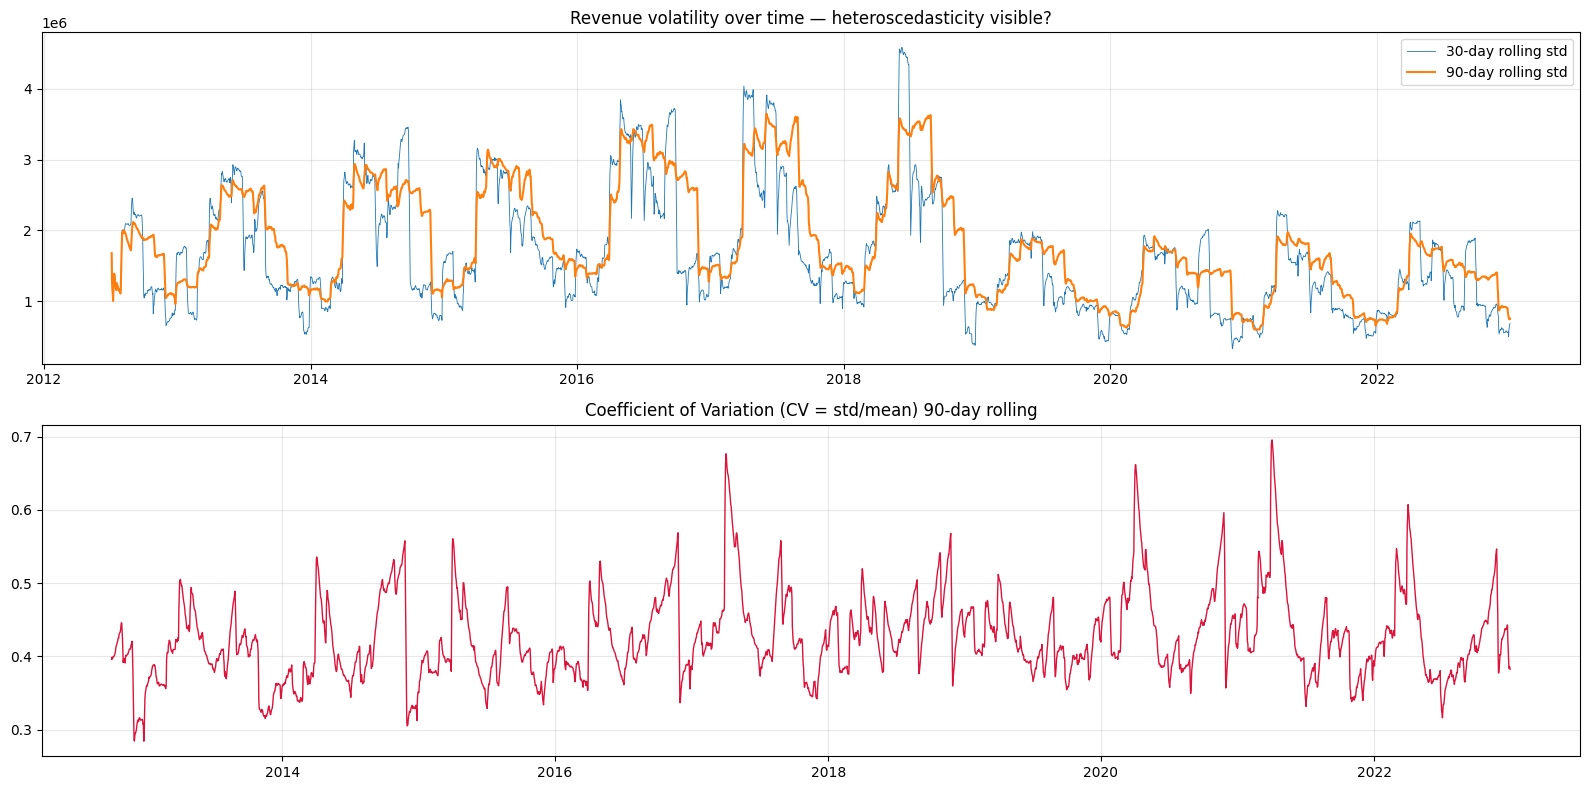

In [15]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))
sales['rev_rollstd_30'] = sales['Revenue'].rolling(30, min_periods=1).std()
sales['rev_rollstd_90'] = sales['Revenue'].rolling(90, min_periods=1).std()
axes[0].plot(sales['Date'], sales['rev_rollstd_30'], lw=0.6, label='30-day rolling std')
axes[0].plot(sales['Date'], sales['rev_rollstd_90'], lw=1.5, label='90-day rolling std')
axes[0].set_title('Revenue volatility over time — heteroscedasticity visible?'); axes[0].legend(); axes[0].grid(alpha=0.3)

# Coefficient of variation
sales['rev_cv_90'] = sales['Revenue'].rolling(90).std() / sales['Revenue'].rolling(90).mean()
axes[1].plot(sales['Date'], sales['rev_cv_90'], color='crimson', lw=1)
axes[1].set_title('Coefficient of Variation (CV = std/mean) 90-day rolling')
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Phân tích 13 — **Test period characteristics** (phân tích ngày trong 2023-2024)

TEST PERIOD (2023-01-01 → 2024-07-01) characteristics:
  Total days:      548
  Weekends:        157
  Tết weeks:       16
  Pre-Tết (≤21d):  42
  11.11 days:      1
  12.12 days:      1
  Days 28-31:      61


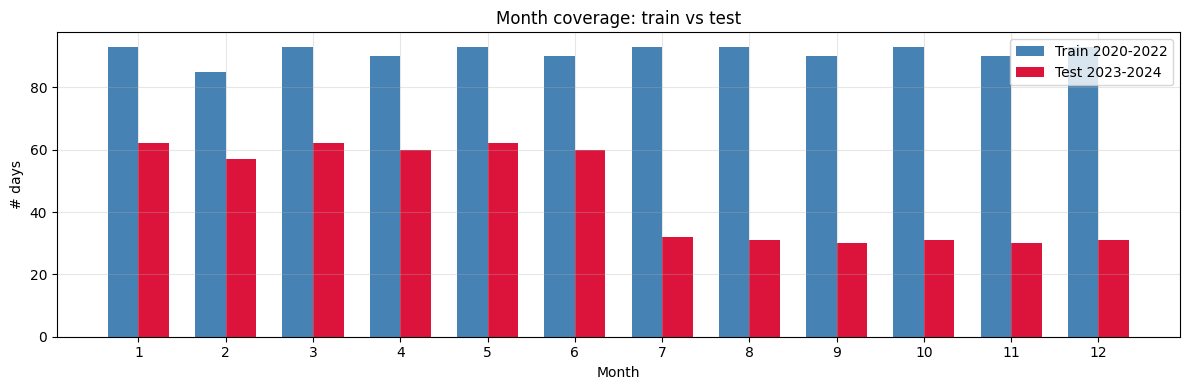


Tết dates during test period:
  2023: 2023-01-22
  2024: 2024-02-10


In [16]:
test_df = submission.copy()
test_df['year']=test_df['Date'].dt.year; test_df['month']=test_df['Date'].dt.month
test_df['day']=test_df['Date'].dt.day; test_df['dow']=test_df['Date'].dt.dayofweek
test_df['days_to_tet'] = test_df['Date'].apply(days_to_tet)

# Event counts in test
print('TEST PERIOD (2023-01-01 → 2024-07-01) characteristics:')
print(f'  Total days:      {len(test_df)}')
print(f'  Weekends:        {(test_df["dow"]>=5).sum()}')
print(f'  Tết weeks:       {test_df["days_to_tet"].between(0,7).sum()}')
print(f'  Pre-Tết (≤21d):  {test_df["days_to_tet"].between(-21,-1).sum()}')
print(f'  11.11 days:      {((test_df["month"]==11)&(test_df["day"]==11)).sum()}')
print(f'  12.12 days:      {((test_df["month"]==12)&(test_df["day"]==12)).sum()}')
print(f'  Days 28-31:      {(test_df["day"]>=28).sum()}')

# Month distribution test
test_months = test_df['month'].value_counts().sort_index()
train_months_recent = sales[sales['year']>=2020]['month'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(1, 13)
w = 0.35
ax.bar(x-w/2, train_months_recent.reindex(x, fill_value=0), w, label='Train 2020-2022', color='steelblue')
ax.bar(x+w/2, test_months.reindex(x, fill_value=0), w, label='Test 2023-2024', color='crimson')
ax.set_xticks(x); ax.set_xlabel('Month'); ax.set_ylabel('# days')
ax.set_title('Month coverage: train vs test'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Tết dates in test
print('\nTết dates during test period:')
for y in [2023, 2024]:
    if y in tet_dates: print(f'  {y}: {tet_dates[y].date()}')

## Phân tích 14 — **Train vs Test distribution gap** (via exogenous proxy)

In [17]:
# Check if exogenous (web_traffic, promotions) cover test period
print('Exogenous coverage in test period 2023-01-01 → 2024-07-01:')
t_start = pd.Timestamp('2023-01-01'); t_end = pd.Timestamp('2024-07-01')
for name, df_x, col in [('Web traffic', web_traffic, 'date'), ('Orders', orders, 'order_date'),
                         ('Promotions start', promotions, 'start_date'),
                         ('Inventory', inventory, 'snapshot_date')]:
    in_test = df_x[(df_x[col]>=t_start)&(df_x[col]<=t_end)]
    pct = len(in_test)/len(df_x)*100
    print(f'  {name:20s}: {len(in_test):>6} rows in test ({pct:.1f}% of total)')
    if len(in_test)>0:
        print(f'    range: {in_test[col].min().date()} → {in_test[col].max().date()}')

# Most important: if web_traffic/promotions DO cover test period,
# we have REAL exogenous data → models can use them directly (NOT seasonal fallback)
# This is a HUGE difference

Exogenous coverage in test period 2023-01-01 → 2024-07-01:
  Web traffic         :      0 rows in test (0.0% of total)
  Orders              :      0 rows in test (0.0% of total)
  Promotions start    :      0 rows in test (0.0% of total)
  Inventory           :      0 rows in test (0.0% of total)


## Phân tích 15 — **STL decomposition: trend + seasonal + residual**

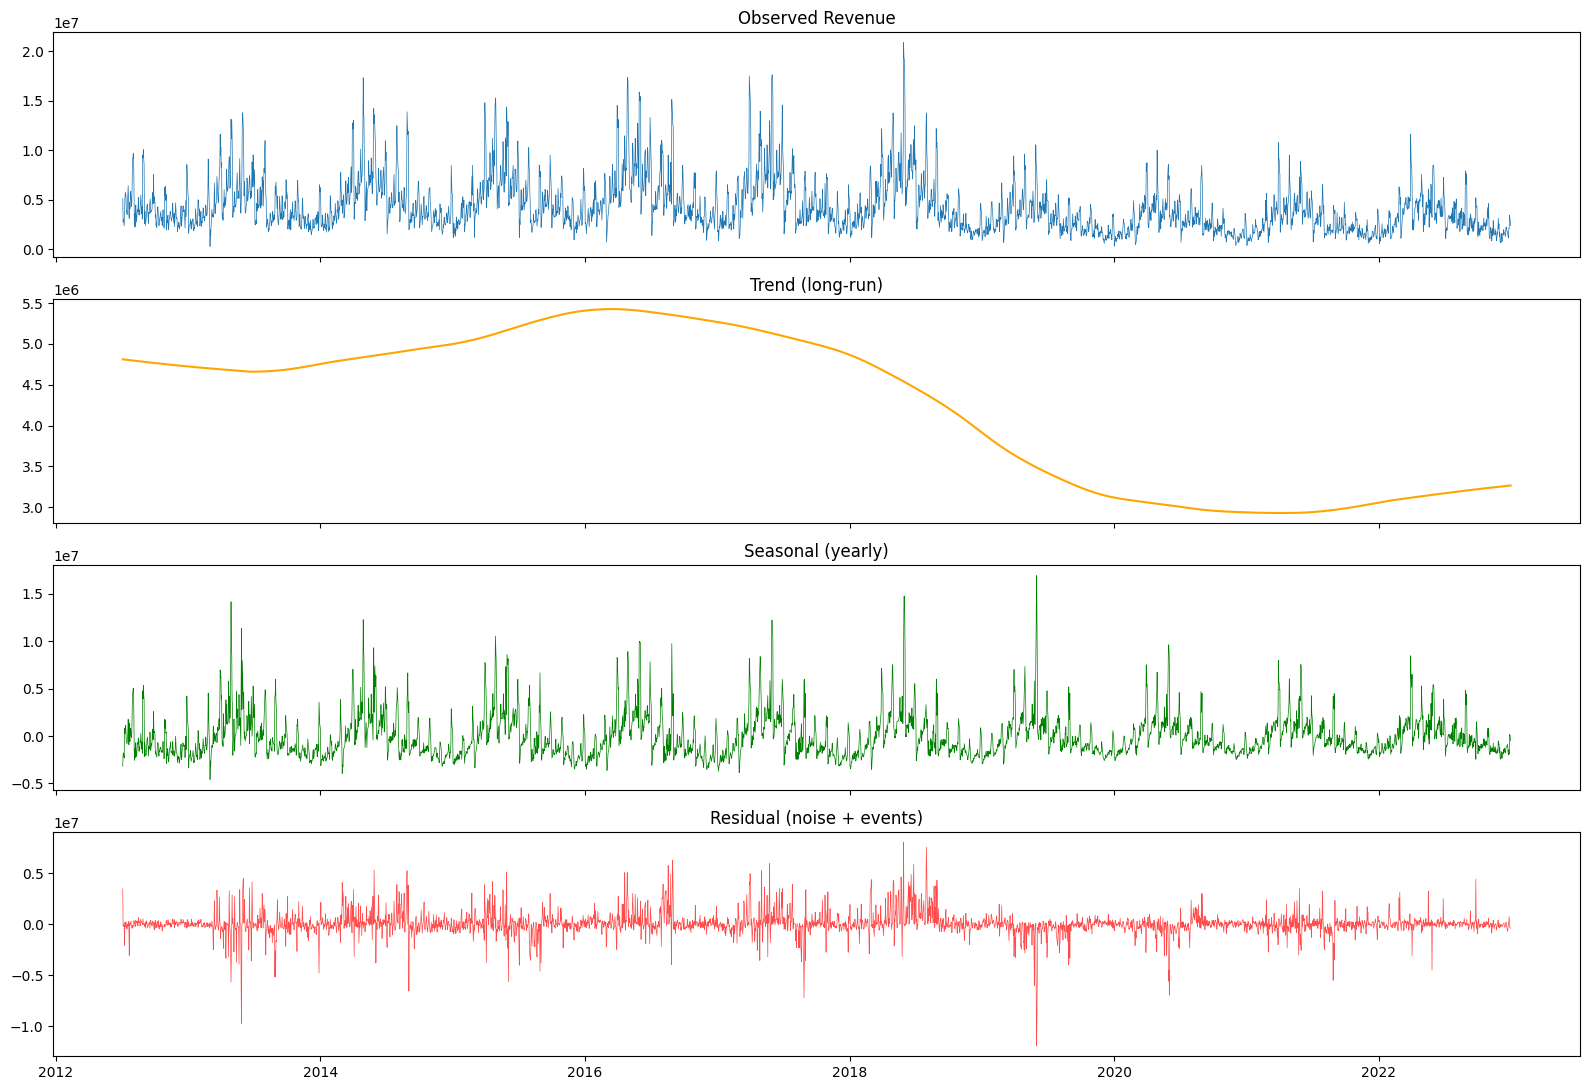

Variance breakdown:
  Trend    :  12.2%
  Seasonal :  73.8%
  Residual :  18.6%
→ Nếu residual >50% → nhiều biến động không giải thích bằng trend+seasonal → cần exogenous


In [18]:
rev_ts = sales.set_index('Date')['Revenue'].asfreq('D').fillna(method='ffill')
stl = STL(rev_ts, period=365, robust=True).fit()

fig, axes = plt.subplots(4, 1, figsize=(16, 11), sharex=True)
axes[0].plot(rev_ts, lw=0.5); axes[0].set_title('Observed Revenue')
axes[1].plot(stl.trend, color='orange', lw=1.5); axes[1].set_title('Trend (long-run)')
axes[2].plot(stl.seasonal, lw=0.5, color='green'); axes[2].set_title('Seasonal (yearly)')
axes[3].plot(stl.resid, lw=0.5, color='red', alpha=0.7); axes[3].set_title('Residual (noise + events)')
plt.tight_layout(); plt.show()

# Variance breakdown
var_total = rev_ts.var()
var_trend = stl.trend.var(); var_seas = stl.seasonal.var(); var_resid = stl.resid.var()
print('Variance breakdown:')
print(f'  Trend    : {var_trend/var_total*100:5.1f}%')
print(f'  Seasonal : {var_seas/var_total*100:5.1f}%')
print(f'  Residual : {var_resid/var_total*100:5.1f}%')
print('→ Nếu residual >50% → nhiều biến động không giải thích bằng trend+seasonal → cần exogenous')

## Tổng kết EDA — các hướng cho v8

Sau khi chạy xong 15 phân tích trên, bạn sẽ có câu trả lời cho:

1. **Regime shift year** → điều chỉnh `recency halflife` hoặc loại bỏ data trước năm đó
2. **Weekly pattern stability** → profile_mdow có outdated không?
3. **J-shape DOM stability** → profile_day có giá trị trong recent data?
4. **Top exogenous correlates** → features nào phải ưu tiên
5. **Promo effect size** → nếu nhỏ (<10%) → bỏ features promo; nếu lớn → ưu tiên
6. **Tết effect direction** (có thể DIP chứ không PEAK!) → rewrite Tết features
7. **Major events magnitude** → đặt weight đúng
8. **Dominant lags** → lag selection dựa trên ACF peaks thực
9. **Stationarity** → có cần differencing không
10. **Outlier pattern** → có nên clip / winsorize trên train không
11. **Margin stability** → Revenue = COGS × margin approach khả thi?
12. **Heteroscedasticity** → log transform đủ không hay cần GARCH-like?
13. **Test period composition** → biết chính xác số ngày Tết, event trong test
14. **Exogenous coverage test** → có thể dùng web_traffic/orders TEST thực không?
15. **Trend vs seasonal vs residual contribution** → model nên focus gì